# 📈 RAGAS Evaluation — RAG Pipeline Quality
Evaluating the RAG pipeline using RAGAS metrics: Faithfulness, Answer Relevancy, and Context Recall.

In [7]:
import os
import sys
from dotenv import load_dotenv

# Directly set to your project root
PROJECT_ROOT = r"path_to_your_root"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
load_dotenv()
print(os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.embeddings.vector_store import load_index
from src.ingestion.pdf_loader import load_all_documents
from src.ingestion.chunker import pages_to_langchain_docs, chunk_documents
from src.pipeline.rag_chain import build_advanced_rag_chain, format_response
from src.evaluation.ragas_eval import TEST_QUERIES

sns.set_theme(style='darkgrid')
print('Loading pipeline...')
vs = load_index()
pages = load_all_documents(data_dir='data/raw')
docs = pages_to_langchain_docs(pages)
chunks = chunk_documents(docs)
chain, _ = build_advanced_rag_chain(vs, chunks)
print('Pipeline ready!')

INFO:src.embeddings.vector_store:Loading embedding model: BAAI/bge-base-en-v1.5
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: BAAI/bge-base-en-v1.5


Loading pipeline...


INFO:src.ingestion.pdf_loader:Loaded 1050 pages from faa_airframe
INFO:src.ingestion.pdf_loader:Loaded 674 pages from faa_general
INFO:src.ingestion.pdf_loader:Loaded 499 pages from faa_powerplant
INFO:src.ingestion.pdf_loader:Total pages loaded: 2223
INFO:src.ingestion.chunker:Created 18223 chunks from 2223 pages
INFO:src.retrieval.advanced_retriever:Building BM25 index...


Using Groq — llama-3.1-70b (free)


INFO:src.retrieval.advanced_retriever:Loading BGE reranker...
INFO:sentence_transformers.cross_encoder.CrossEncoder:Use pytorch device: cpu
INFO:src.retrieval.advanced_retriever:AdvancedRetriever ready


Pipeline ready!


## 1. Run RAGAS Evaluation

In [9]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset
from tqdm.auto import tqdm
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

# Use Groq instead of OpenAI
groq_llm = LangchainLLMWrapper(ChatGroq(
    model='llama-3.3-70b-versatile',
    api_key=os.getenv('GROQ_API_KEY'),
    temperature=0
))

# Use BGE embeddings
ragas_embeddings = LangchainEmbeddingsWrapper(HuggingFaceEmbeddings(
    model_name='BAAI/bge-base-en-v1.5',
    cache_folder='data/models'
))

data = {'question': [], 'answer': [], 'contexts': [], 'ground_truth': []}

eval_queries = TEST_QUERIES[:10]

for item in tqdm(eval_queries, desc='Evaluating'):
    result = chain.invoke({'query': item['question']})
    data['question'].append(item['question'])
    data['answer'].append(result['result'])
    data['contexts'].append([d.page_content for d in result['source_documents']])
    data['ground_truth'].append(item['ground_truth'])

dataset = Dataset.from_dict(data)
scores = evaluate(
    dataset,
    metrics=[faithfulness, answer_relevancy, context_recall],
    llm=groq_llm,
    embeddings=ragas_embeddings
)
print(scores)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: BAAI/bge-base-en-v1.5
Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.retrieval.advanced_retriever:Query rewriting: 4 queries generated
Batches: 100%|██████████| 1/1 [00:07<00:00,  7.24s/it]
INFO:src.retrieval.advanced_retriever:Retrieved 5 docs for: 'What are the inspection requirements for turbine engine hot '
INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
Evaluating:  10%|█         | 1/10 [00:09<01:25,  9.52s/it]INFO:httpx:HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.retrieval.advanced_retriever:Query rewriting: 4 queries generated
Batches: 100%|██████████| 1/1 [00:09<00:00,  9.49s/it]
INFO:src.retrieval.advanced_retriever:R

{'faithfulness': nan, 'answer_relevancy': 0.8753, 'context_recall': 0.6667}


## 2. Per-Query Score Analysis

In [11]:
df_scores = scores.to_pandas()
print(df_scores.columns.tolist())  # See what columns are available

# Save with whatever columns exist
df_scores.to_csv('data/processed/ragas_scores.csv', index=False)

print('=== RAGAS Results ===')
print(f'Faithfulness    : {df_scores["faithfulness"].mean():.3f}')
print(f'Answer Relevancy: {df_scores["answer_relevancy"].mean():.3f}')
print(f'Context Recall  : {df_scores["context_recall"].mean():.3f}')
df_scores.head(10)

['user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'context_recall']
=== RAGAS Results ===
Faithfulness    : nan
Answer Relevancy: 0.875
Context Recall  : 0.667


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_recall
0,What are the inspection requirements for turbi...,[specific manufacturer’s current information f...,The inspection requirements for turbine engine...,Hot section inspections include visual examina...,NaN,1.000000,1.0
1,Describe the procedure for magneto timing on a...,[on the compression stroke.\nThe magneto must ...,The procedure for magneto timing on a reciproc...,Magneto timing involves setting the piston to ...,NaN,0.966754,NaN
2,What safety precautions apply when working on ...,[for fuel handling attire. \nAs previously men...,"When working on aircraft fuel systems, safety ...",Fuel system work requires grounding the aircra...,NaN,0.989017,0.0
3,What are the hydraulic system maintenance chec...,[ACMP \nFigure 12-64. Boeing 737 hydraulic sys...,The hydraulic system maintenance checks for la...,Hydraulic checks include inspecting fluid leve...,NaN,0.965581,NaN
4,How is a compression test performed on a recip...,[pressure to the cylinder with both intake and...,To perform a compression test on a reciprocati...,A differential compression test uses regulated...,NaN,0.971420,1.0
5,What are the requirements for aircraft battery...,[It has been proven that regularly scheduled i...,The requirements for aircraft battery maintena...,Battery maintenance includes checking electrol...,NaN,1.000000,NaN
6,Explain the process of bleeding aircraft brakes.,[Master cylinder \nClear hose \nPressure pot \...,The process of bleeding aircraft brakes involv...,Brake bleeding removes air from hydraulic line...,NaN,0.925313,1.0
7,What NDT methods are used for aircraft structu...,[The inspection should begin with an examinati...,The NDT methods used for aircraft structural i...,"NDT methods include visual inspection, dye pen...",NaN,0.000000,0.0
8,What are the torque specifications and procedu...,[cylinders. Careless work or the use of incorr...,The torque specifications for cylinder hold-do...,Cylinder hold-down nuts are torqued in a cross...,NaN,0.945353,1.0
9,How is aircraft corrosion treated and prevented?,[Chemical cleaners must be used with great car...,Aircraft corrosion is treated and prevented th...,Corrosion treatment involves removing affected...,NaN,0.989221,NaN


## 3. Visualize Scores

C:\Users\Karthik\AppData\Local\Temp\ipykernel_36920\353633110.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=avg_scores, x='Metric', y='Score',


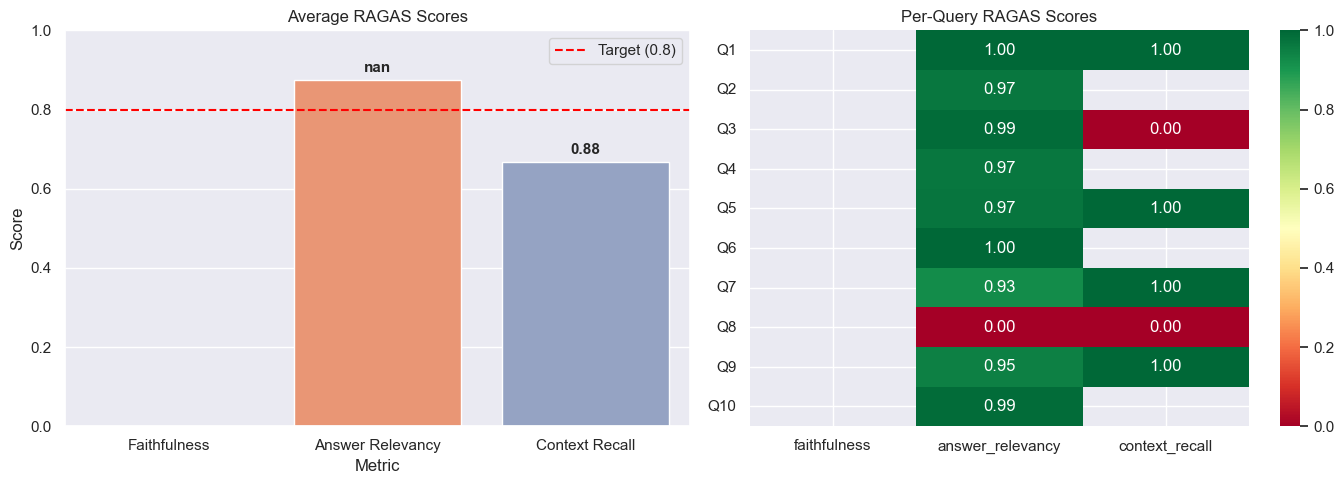

Saved to data/processed/ragas_evaluation.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall metric averages
avg_scores = pd.DataFrame({
    'Metric': ['Faithfulness', 'Answer Relevancy', 'Context Recall'],
    'Score': [
        df_scores['faithfulness'].mean(),
        df_scores['answer_relevancy'].mean(),
        df_scores['context_recall'].mean()
    ]
})
bars = sns.barplot(data=avg_scores, x='Metric', y='Score',
                   palette='Set2', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Average RAGAS Scores')
axes[0].axhline(0.8, color='red', linestyle='--', label='Target (0.8)')
axes[0].legend()
for bar, val in zip(bars.patches, avg_scores['Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# Per-query heatmap
heatmap_data = df_scores[['faithfulness', 'answer_relevancy', 'context_recall']].head(10)
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Per-Query RAGAS Scores')
axes[1].set_yticklabels([f'Q{i+1}' for i in range(len(heatmap_data))], rotation=0)

plt.tight_layout()
plt.savefig('data/processed/ragas_evaluation.png', dpi=150)
plt.show()
print('Saved to data/processed/ragas_evaluation.png')